In [26]:
import pandas as pd
import importlib
import sys
sys.path.append("/home/nichettg/Linux Programmi/Codici")

import funzioni as f
importlib.reload(f)
import math
import numpy as np

import grafici as gf
importlib.reload(gf)
import matplotlib.pyplot as plt
import itertools


colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
color_cycle = itertools.cycle(colors)
markers = ['o','s','^','D','v']
marker_cycle = itertools.cycle(markers)

errori = gf.default_error_params()
gf.imposta_stile_globale()

### 1.1 Raccolta Dati

In [27]:
sT = 0.1 / math.sqrt(12)

dati = pd.read_csv('dati.csv')

segmenti = [(0, 18), (18, 46), (46, len(dati))]

def estrazione_dati(dati, segmenti):
    t = []
    T = []
    for start, end in segmenti:
        serie_in_dati = dati.iloc[start:end]
        t.append(serie_in_dati["tempo"].to_numpy())
        T.append(serie_in_dati["temperatura"].to_numpy())
    return t, T

vt, vT = estrazione_dati(dati, segmenti)

print("vt:", vt)
print("vT:", vT)


vt: [array([149.7, 164.7, 179.7, 194.7, 209.7, 239.7, 269.7, 299.7, 329.7,
       359.7, 389.7, 419.7, 449.7, 509.7, 569.7, 629.7, 689.7, 749.7]), array([ 113.,  128.,  143.,  158.,  173.,  203.,  233.,  263.,  293.,
        323.,  353.,  383.,  413.,  473.,  533.,  593.,  653.,  713.,
        773.,  833.,  893.,  953., 1013., 1073., 1133., 1193., 1253.,
       1313.]), array([ 15.,  30.,  45.,  60.,  75.,  90., 105., 120., 135., 150., 165.,
       195., 225., 255., 285., 315., 345., 375., 405., 435., 465., 495.,
       525., 555., 585., 615., 645., 675., 705.])]
vT: [array([25.9, 25.8, 25.8, 25.8, 25.8, 25.8, 25.8, 25.8, 25.7, 25.7, 25.7,
       25.7, 25.7, 25.7, 25.6, 25.6, 25.6, 25.6]), array([29.7, 29.7, 29.6, 29.6, 29.6, 29.6, 29.5, 29.5, 29.5, 29.5, 29.4,
       29.4, 29.4, 29.3, 29.3, 29.2, 29.2, 29.1, 29.1, 29. , 29. , 28.9,
       28.9, 28.9, 28.8, 28.8, 28.8, 28.7]), array([27.3, 28.4, 29.4, 30. , 31.3, 31.7, 31.7, 31.7, 31.7, 31.7, 31.6,
       31.6, 31.6, 31.5, 31.5, 31.4, 

### 1.2 Interpolazione

In [28]:
va1, vb1, vsa1, vsb1 = [], [], [], []
output_name = "interpolazione1.txt"
f.output_init(output_name)

for i in range(len(vt)):
    if i == 2:
        vx, vy = [], []
        for j in range(4, len(vt[i])):
            vx.append(vt[i][j])
            vy.append(vT[i][j])
        a, b, sa, sb = f.elaborato(vx, vy, sT, output_name, i, ritorno = True)
    else:
        a,b,sa,sb = f.elaborato(vt[i], vT[i], sT, output_name, i, ritorno = True)
    va1.append(a)
    vb1.append(b)
    vsa1.append(sa)
    vsb1.append(sb)

del vx, vy

Minimi quadrati I
Processo al calcolatore

Minimi quadrati I
Processo al calcolatore

Minimi quadrati I
Processo al calcolatore



### 1.3 Grafico Lineare

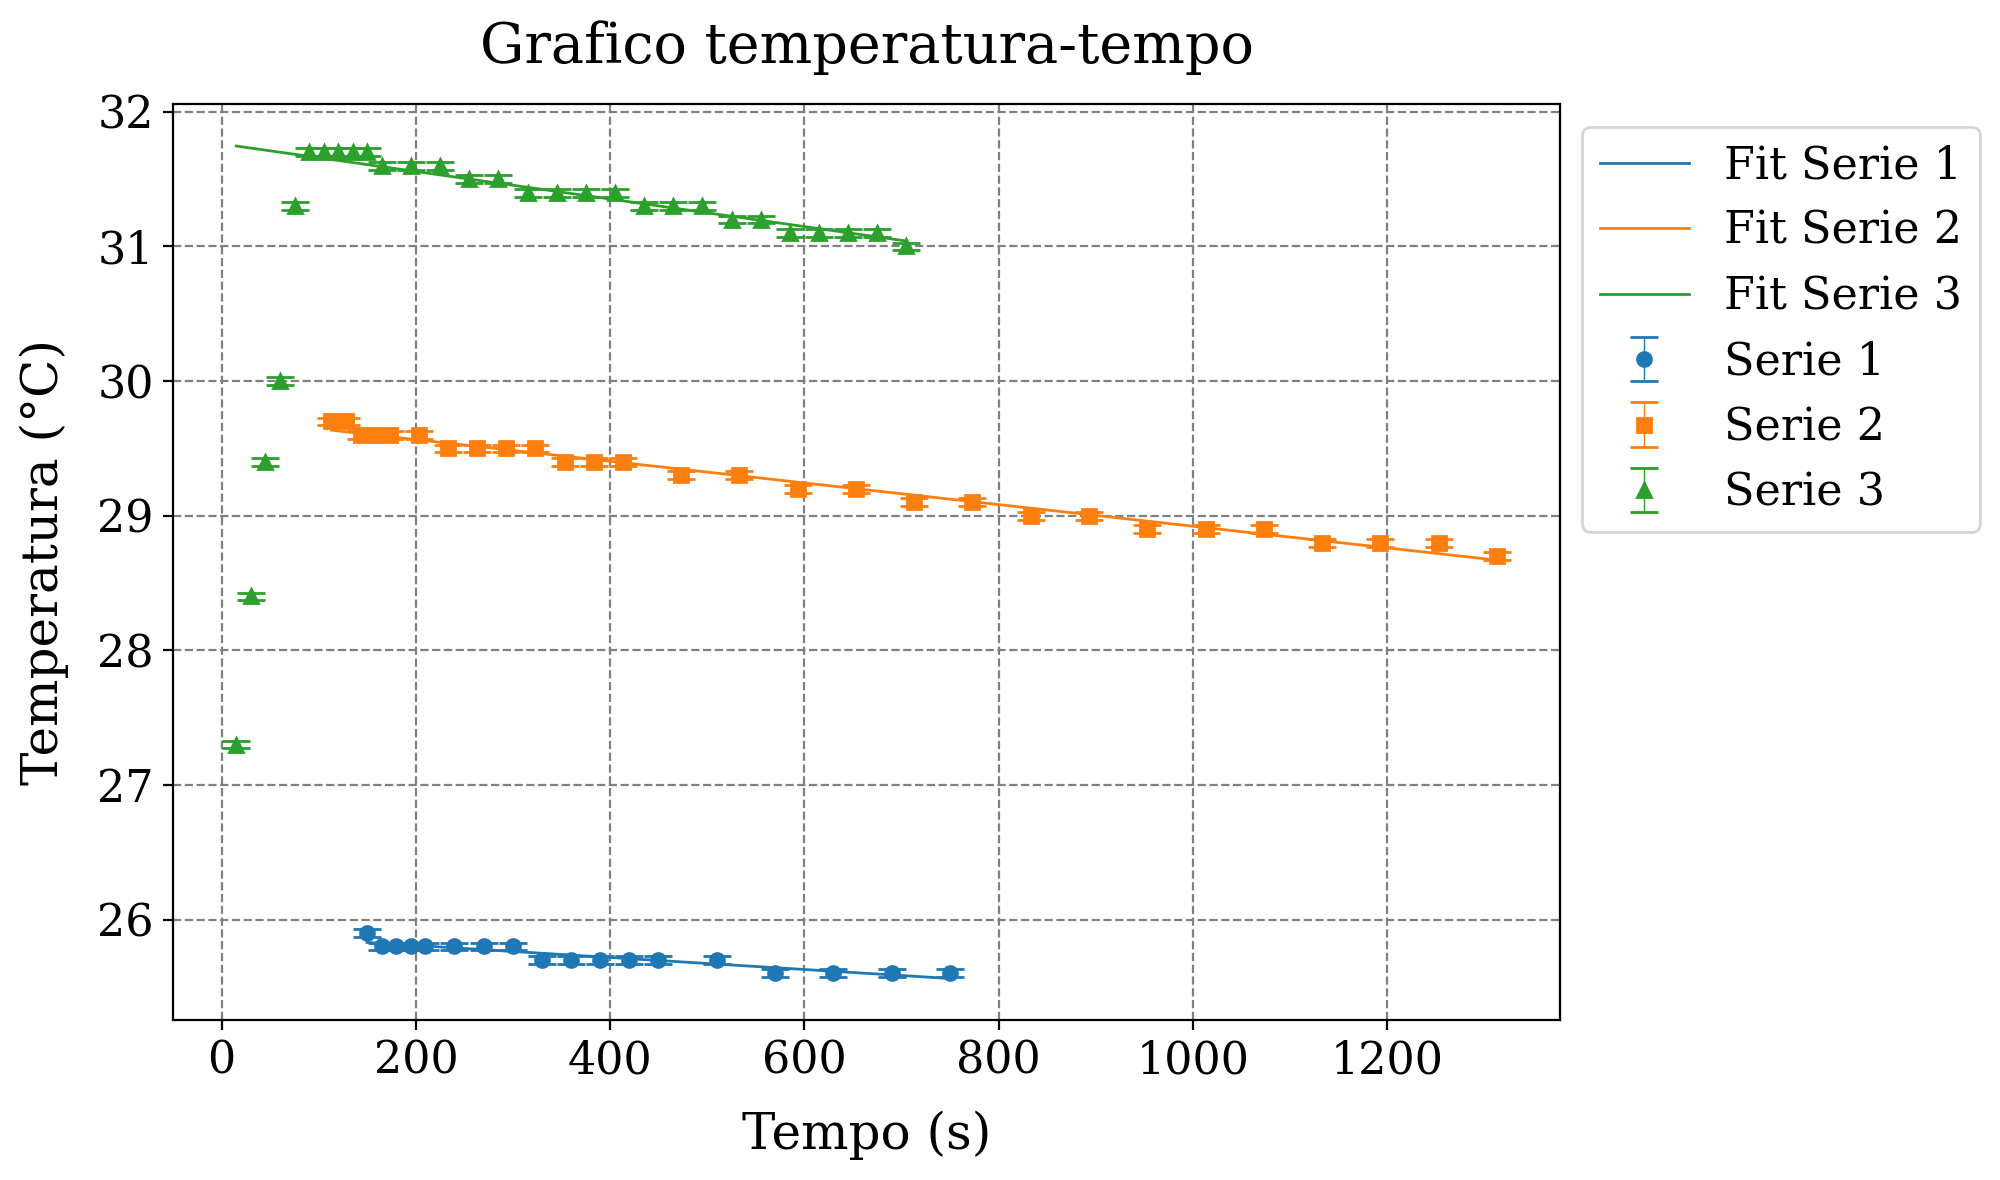

In [29]:
fig, ax = plt.subplots()

for i in range(len(vt)):
    color = next(color_cycle)
    label = f"Serie {i+1}"
    marker = next(marker_cycle)
    ax.errorbar(vt[i], vT[i], yerr=sT, fmt=marker, color=color, markersize = 5, label = label, **errori)

    x_values = np.linspace(min(vt[i]), max(vt[i]), 100)
    y_values = va1[i] + vb1[i] * x_values
    ax.plot(x_values, y_values, color=color, linestyle='-', linewidth = 1, label=f"Fit {label}")


gf.setup_2d_axes(ax, titolo = "Grafico temperatura-tempo", xlabel = "Tempo (s)", ylabel = "Temperatura (°C)")

gf.salva_figura("grafico1.pdf")